# M2-B1 — Audit et industrialisation du pipeline Banque Eckmühl

**Auteur :** Fernando  
**Dataset :** German Credit  
**Objectif :** auditer la qualité et les risques éthiques du dataset, puis construire un pipeline de préparation réutilisable et persistable.

## 0. Setup

In [223]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "german_credit_raw.csv"
SUPPLEMENT_DATA_PATH = DATA_DIR / "german_credit_supplement.csv"

TARGET_COLUMN = "credit_risk"
POSITIVE_LABEL = "good_credit"

In [224]:
print("Project root:", PROJECT_ROOT)
print("Raw dataset exists:", RAW_DATA_PATH.exists())
print("Supplement exists:", SUPPLEMENT_DATA_PATH.exists())

Project root: /Users/fernando/Documents/devid/formation-ai/M2-B1-pipe-eckmuhl-fernando
Raw dataset exists: True
Supplement exists: True


## 1. Découverte du dataset

Le dataset contient des dossiers de crédit à la consommation.  
Chaque ligne correspond à un dossier client.

La cible `credit_risk` contient deux résultats :

- `good_credit` : résultat favorable ;
- `bad_credit` : résultat défavorable.

In [226]:
df = pd.read_csv(RAW_DATA_PATH)
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,n_existing_credits,job,n_people_liable,telephone,foreign_worker,credit_risk
0,< 0 DM,6,critical account / other credits existing,radio/TV,1169,unknown / no savings,>= 7 years,4,male single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered",yes,good_credit
1,0 to 200 DM,48,existing credits paid back duly,radio/TV,5951,< 100 DM,1-4 years,2,female divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,none,yes,bad_credit
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good_credit
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male single,guarantor,...,savings agreement / life insurance,45,none,for free,1,skilled employee / official,2,none,yes,good_credit
4,< 0 DM,24,delay in paying off in past,car (new),4870,< 100 DM,1-4 years,3,male single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes,bad_credit


In [227]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre total de colonnes : {df.shape[1]}")
print(f"Nombre de features : {df.shape[1] - 1}")

Nombre de lignes : 1000
Nombre total de colonnes : 21
Nombre de features : 20


In [228]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   checking_account_status      1000 non-null   object
 1   duration_months              1000 non-null   int64 
 2   credit_history               1000 non-null   object
 3   purpose                      1000 non-null   object
 4   credit_amount                1000 non-null   int64 
 5   savings_account              1000 non-null   object
 6   employment_since             1000 non-null   object
 7   installment_rate_pct_income  1000 non-null   int64 
 8   personal_status_sex          1000 non-null   object
 9   other_debtors                1000 non-null   object
 10  residence_since_years        1000 non-null   int64 
 11  property                     1000 non-null   object
 12  age                          1000 non-null   int64 
 13  other_installment_plans      1000 

In [229]:
schema = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_rate_pct": df.isna().mean().mul(100).round(2).values,
        "unique_values": df.nunique(dropna=False).values,
    }
)

schema

,column,dtype,missing_count,missing_rate_pct,unique_values
0,checking_account_status,object,0,0.0,4
1,duration_months,int64,0,0.0,33
2,credit_history,object,0,0.0,5
3,purpose,object,0,0.0,10
4,credit_amount,int64,0,0.0,921
5,savings_account,object,0,0.0,5
6,employment_since,object,0,0.0,5
7,installment_rate_pct_income,int64,0,0.0,4
8,personal_status_sex,object,0,0.0,4
9,other_debtors,object,0,0.0,3


### Types de variables

Le dataset contient :

- des variables numériques continues ou discrètes ;
- des variables catégorielles nominales ;
- des variables potentiellement ordinales ;
- une cible binaire ;
- plusieurs variables sensibles ou susceptibles de produire des biais.

In [231]:
numeric_features = df.select_dtypes(include="number").columns.tolist()

categorical_features = (
    df.select_dtypes(include=["object", "category"])
    .columns
    .drop(TARGET_COLUMN)
    .tolist()
)

sensitive_features = [
    "age",
    "personal_status_sex",
    "foreign_worker",
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nSensitive features:")
print(sensitive_features)

Numerical features:
['duration_months', 'credit_amount', 'installment_rate_pct_income', 'residence_since_years', 'age', 'n_existing_credits', 'n_people_liable']

Categorical features:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Sensitive features:
['age', 'personal_status_sex', 'foreign_worker']


### Variables sensibles identifiées

Trois variables demandent une attention particulière :

- `age` : l'âge peut influencer directement ou indirectement une décision de crédit ;
- `personal_status_sex` : cette variable combine le sexe et la situation matrimoniale, ce qui empêche d'analyser séparément ces deux dimensions ;
- `foreign_worker` : cette variable distingue les travailleurs étrangers des autres clients.

La variable `personal_status_sex` constitue un problème de conception, car les catégories masculines et féminines ne sont pas représentées de manière symétrique.

In [233]:
target_counts = df[TARGET_COLUMN].value_counts()
target_percentages = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame(
    {
        "count": target_counts,
        "percentage": target_percentages,
    }
)

target_summary

,count,percentage
credit_risk,,
good_credit,700,70.0
bad_credit,300,30.0


La cible est déséquilibrée :

- 700 dossiers, soit 70 %, sont classés `good_credit` ;
- 300 dossiers, soit 30 %, sont classés `bad_credit`.

Le déséquilibre n'est pas extrême, mais il devra être pris en compte dans l'analyse éthique et dans un éventuel futur entraînement de modèle.

In [235]:
## 2. Audit qualité

In [236]:
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_rate_pct": df.isna().mean().mul(100).round(2),
        }
    )
    .sort_values("missing_rate_pct", ascending=False)
)

missing_summary

,missing_count,missing_rate_pct
checking_account_status,0,0.0
property,0,0.0
foreign_worker,0,0.0
telephone,0,0.0
n_people_liable,0,0.0
job,0,0.0
n_existing_credits,0,0.0
housing,0,0.0
other_installment_plans,0,0.0
age,0,0.0


In [237]:
missing_summary.query("missing_count > 0")

,missing_count,missing_rate_pct


### Valeurs manquantes

Le fichier brut ne contient pas nécessairement de valeurs `NaN` détectées directement par Pandas.

Cependant, certaines modalités comme `unknown / no savings` ou `unknown / no property` regroupent une absence d'information avec une situation métier réelle. Il existe donc des valeurs manquantes ou ambiguës au niveau sémantique, même si elles ne sont pas techniquement vides.

In [239]:
duplicate_count = int(df.duplicated().sum())
duplicate_rate = round(df.duplicated().mean() * 100, 2)

print("Duplicate rows:", duplicate_count)
print("Duplicate rate:", duplicate_rate, "%")

Duplicate rows: 0
Duplicate rate: 0.0 %


In [240]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate_pct_income,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since_years,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
n_existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
n_people_liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [241]:
quality_checks = {
    "age_not_positive": int((df["age"] <= 0).sum()),
    "duration_not_positive": int((df["duration_months"] <= 0).sum()),
    "credit_amount_not_positive": int((df["credit_amount"] <= 0).sum()),
    "installment_rate_not_positive": int(
        (df["installment_rate_pct_income"] <= 0).sum()
    ),
    "people_liable_not_positive": int(
        (df["n_people_liable"] <= 0).sum()
    ),
}

pd.Series(quality_checks, name="invalid_count")

age_not_positive                 0
duration_not_positive            0
credit_amount_not_positive       0
installment_rate_not_positive    0
people_liable_not_positive       0
Name: invalid_count, dtype: int64

##

### Cohérence des modalités catégorielles

Les variables catégorielles sont contrôlées afin d'identifier :

- les différences de casse ;
- les espaces parasites ;
- les modalités rares ;
- les catégories ambiguës ;
- les valeurs représentant indirectement une information inconnue.

In [244]:
categorical_features = (
    df.select_dtypes(include=["object", "category"])
    .columns
    .drop(TARGET_COLUMN)
    .tolist()
)

categorical_summary = []

for column in categorical_features:
    value_counts = df[column].value_counts(dropna=False)

    categorical_summary.append(
        {
            "column": column,
            "n_unique": df[column].nunique(dropna=False),
            "most_frequent_value": value_counts.index[0],
            "most_frequent_count": int(value_counts.iloc[0]),
            "rarest_value_count": int(value_counts.iloc[-1]),
        }
    )

categorical_summary_df = pd.DataFrame(categorical_summary)

categorical_summary_df

,column,n_unique,most_frequent_value,most_frequent_count,rarest_value_count
0,checking_account_status,4,no checking account,394,63
1,credit_history,5,existing credits paid back duly,530,40
2,purpose,10,radio/TV,280,9
3,savings_account,5,< 100 DM,603,48
4,employment_since,5,1-4 years,339,62
5,personal_status_sex,4,male single,548,50
6,other_debtors,3,none,907,41
7,property,4,car or other,332,154
8,other_installment_plans,3,none,814,47
9,housing,3,own,713,108


In [245]:
whitespace_issues = {}

for column in categorical_features:
    string_values = df[column].dropna().astype(str)

    issue_count = (
        string_values.ne(string_values.str.strip())
    ).sum()

    whitespace_issues[column] = int(issue_count)

pd.Series(whitespace_issues, name="whitespace_issue_count")

checking_account_status    0
credit_history             0
purpose                    0
savings_account            0
employment_since           0
personal_status_sex        0
other_debtors              0
property                   0
other_installment_plans    0
housing                    0
job                        0
telephone                  0
foreign_worker             0
Name: whitespace_issue_count, dtype: int64

In [246]:
rare_modalities = {}

for column in categorical_features:
    counts = df[column].value_counts(dropna=False)
    rare_modalities[column] = counts[counts < 20].to_dict()

rare_modalities

{'checking_account_status': {},
 'credit_history': {},
 'purpose': {'domestic appliances': 12, 'others': 12, 'retraining': 9},
 'savings_account': {},
 'employment_since': {},
 'personal_status_sex': {},
 'other_debtors': {},
 'property': {},
 'other_installment_plans': {},
 'housing': {},
 'job': {},
 'telephone': {},
 'foreign_worker': {}}

In [247]:
def calculate_iqr_outliers(
    data: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    results: list[dict[str, float | int | str]] = []

    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (
            data[column].lt(lower_bound)
            | data[column].gt(upper_bound)
        )

        outlier_count = int(outlier_mask.sum())

        results.append(
            {
                "column": column,
                "q1": round(float(q1), 2),
                "q3": round(float(q3), 2),
                "lower_bound": round(float(lower_bound), 2),
                "upper_bound": round(float(upper_bound), 2),
                "outlier_count": outlier_count,
                "outlier_rate_pct": round(
                    outlier_count / len(data) * 100,
                    2,
                ),
            }
        )

    return pd.DataFrame(results).sort_values(
        "outlier_count",
        ascending=False,
    )


outlier_summary = calculate_iqr_outliers(
    data=df,
    columns=numeric_features,
)

outlier_summary

,column,q1,q3,lower_bound,upper_bound,outlier_count,outlier_rate_pct
6,n_people_liable,1.0,1.00,1.00,1.00,155,15.5
1,credit_amount,1365.5,3972.25,-2544.62,7882.38,72,7.2
0,duration_months,12.0,24.00,-6.00,42.00,70,7.0
4,age,27.0,42.00,4.50,64.50,23,2.3
5,n_existing_credits,1.0,2.00,-0.50,3.50,6,0.6
2,installment_rate_pct_income,2.0,4.00,-1.00,7.00,0,0.0
3,residence_since_years,2.0,4.00,-1.00,7.00,0,0.0


### Valeurs atypiques

Les valeurs atypiques sont détectées avec la méthode de l'écart interquartile
(IQR).

Une valeur atypique n'est pas automatiquement une erreur. Dans un contexte
de crédit, un montant élevé ou une longue durée de remboursement peuvent être
rares tout en restant légitimes.

Les lignes concernées ne sont donc pas supprimées automatiquement. Elles sont
documentées et conservées, sauf incohérence métier démontrée.

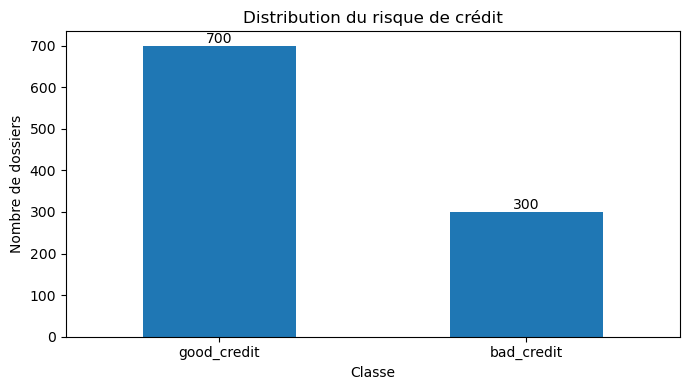

In [249]:
target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(["good_credit", "bad_credit"])
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("Distribution du risque de crédit")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre de dossiers")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

La cible présente un déséquilibre modéré : 70 % des dossiers sont classés
`good_credit`, contre 30 % classés `bad_credit`.

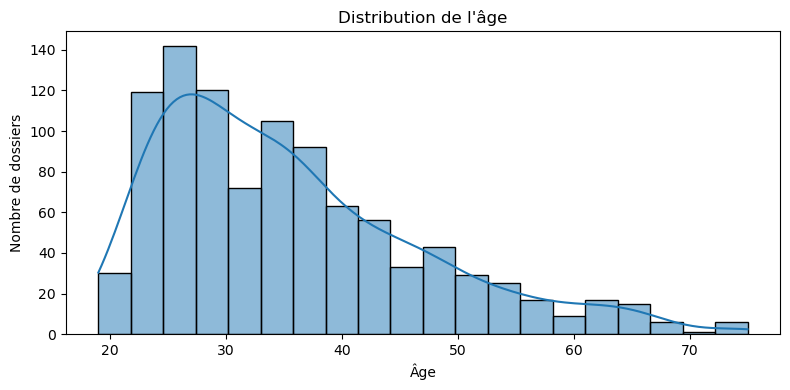

In [251]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True,
)

plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()

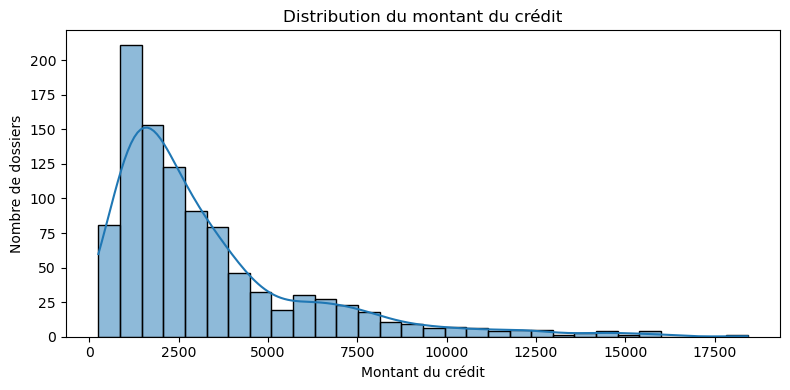

In [252]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="credit_amount",
    bins=30,
    kde=True,
)

plt.title("Distribution du montant du crédit")
plt.xlabel("Montant du crédit")
plt.ylabel("Nombre de dossiers")
plt.tight_layout()
plt.show()

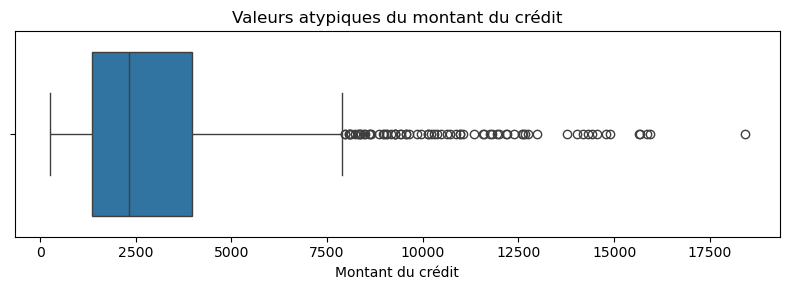

In [253]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="credit_amount",
)

plt.title("Valeurs atypiques du montant du crédit")
plt.xlabel("Montant du crédit")
plt.tight_layout()
plt.show()

In [254]:
foreign_worker_crosstab = pd.crosstab(
    df["foreign_worker"],
    df[TARGET_COLUMN],
    normalize="index",
).mul(100)

foreign_worker_crosstab

credit_risk,bad_credit,good_credit
foreign_worker,,
no,10.810811,89.189189
yes,30.737279,69.262721


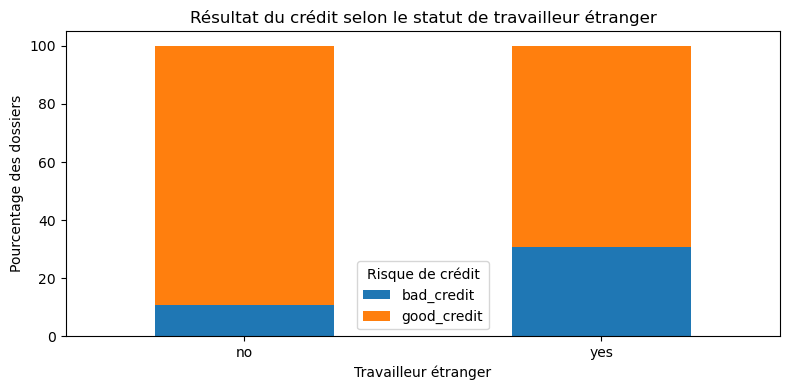

In [255]:
ax = foreign_worker_crosstab.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
)

ax.set_title("Résultat du crédit selon le statut de travailleur étranger")
ax.set_xlabel("Travailleur étranger")
ax.set_ylabel("Pourcentage des dossiers")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Risque de crédit")

plt.tight_layout()
plt.show()

### Verdict qualité

L'audit du dataset met en évidence les constats suivants :

1. Le fichier brut contient **X valeurs manquantes techniques**, soit **Y %**
   des cellules. Certaines modalités comme `unknown / no savings` ou
   `unknown / no property` restent néanmoins ambiguës sur le plan métier,
   car elles regroupent une information inconnue et une situation réelle.

2. Le dataset contient **X lignes dupliquées**, soit **Y %** des 1 000
   observations.

3. La variable `credit_amount` contient **X valeurs atypiques selon la méthode
   IQR**, soit **Y %** des dossiers. Ces valeurs sont conservées car elles
   peuvent représenter des crédits rares mais légitimes.

4. La variable `foreign_worker` est très déséquilibrée : **963 dossiers
   indiquent `yes` et seulement 37 indiquent `no`**. Cette faible
   représentation devra être prise en compte dans l'interprétation de
   l'audit éthique.

5. La variable `personal_status_sex` combine sexe et situation matrimoniale.
   Ses catégories sont asymétriques et rendent impossible une analyse
   indépendante de ces deux dimensions.

Conclusion : le dataset est globalement exploitable, mais plusieurs limites
doivent être documentées avant toute mise en production, notamment les
modalités ambiguës, les valeurs atypiques et la représentation déséquilibrée
de certains groupes.

## 3. Audit éthique léger

L'objectif est d'identifier et de quantifier d'éventuels écarts de résultats
entre différents groupes.

L'issue positive est `good_credit`.

Le disparate impact est calculé comme suit :

DI = taux de résultat positif du groupe protégé / taux de résultat positif du groupe de référence

Selon la règle des quatre cinquièmes :

- DI inférieur à 0,8 : signal d'alerte ;
- DI entre 0,8 et 1,25 : aucun signal fort selon ce seuil ;
- DI supérieur à 1,25 : disparité dans le sens opposé.

Cet indicateur signale un écart statistique, mais ne prouve pas à lui seul
une discrimination.

In [258]:
df_ethics = df.copy()

df_ethics["positive_outcome"] = (
    df_ethics[TARGET_COLUMN]
    .eq(POSITIVE_LABEL)
    .astype(int)
)

df_ethics[
    [TARGET_COLUMN, "positive_outcome"]
].head()

,credit_risk,positive_outcome
0,good_credit,1
1,bad_credit,0
2,good_credit,1
3,good_credit,1
4,bad_credit,0


In [259]:
def positive_rates_by_group(
    data: pd.DataFrame,
    sensitive_column: str,
) -> pd.DataFrame:
    summary = (
        data.groupby(
            sensitive_column,
            dropna=False,
        )["positive_outcome"]
        .agg(
            positive_rate="mean",
            group_size="count",
            positive_count="sum",
        )
        .reset_index()
    )

    summary["positive_rate_pct"] = (
        summary["positive_rate"]
        .mul(100)
        .round(2)
    )

    return summary.sort_values(
        "positive_rate",
        ascending=False,
    )


def calculate_disparate_impact(
    data: pd.DataFrame,
    sensitive_column: str,
    protected_group: str,
    reference_group: str,
) -> dict[str, float | str]:
    rates = (
        data.groupby(sensitive_column)["positive_outcome"]
        .mean()
    )

    protected_rate = float(rates.loc[protected_group])
    reference_rate = float(rates.loc[reference_group])

    if reference_rate == 0:
        raise ValueError(
            "The reference group has a zero positive rate."
        )

    disparate_impact = protected_rate / reference_rate

    return {
        "sensitive_variable": sensitive_column,
        "protected_group": protected_group,
        "reference_group": reference_group,
        "protected_positive_rate": round(protected_rate, 4),
        "reference_positive_rate": round(reference_rate, 4),
        "disparate_impact": round(disparate_impact, 4),
    }

In [260]:
foreign_worker_rates = positive_rates_by_group(
    data=df_ethics,
    sensitive_column="foreign_worker",
)

foreign_worker_rates

,foreign_worker,positive_rate,group_size,positive_count,positive_rate_pct
0,no,0.891892,37,33,89.19
1,yes,0.692627,963,667,69.26


In [261]:
foreign_worker_di = calculate_disparate_impact(
    data=df_ethics,
    sensitive_column="foreign_worker",
    protected_group="yes",
    reference_group="no",
)

foreign_worker_di

{'sensitive_variable': 'foreign_worker',
 'protected_group': 'yes',
 'reference_group': 'no',
 'protected_positive_rate': 0.6926,
 'reference_positive_rate': 0.8919,
 'disparate_impact': 0.7766}

In [262]:
foreign_worker_di_value = foreign_worker_di["disparate_impact"]

if foreign_worker_di_value < 0.8:
    foreign_worker_interpretation = (
        "Signal d'alerte : le disparate impact est inférieur à 0,8."
    )
elif foreign_worker_di_value > 1.25:
    foreign_worker_interpretation = (
        "Signal de disparité inverse : le disparate impact dépasse 1,25."
    )
else:
    foreign_worker_interpretation = (
        "Aucun signal fort selon la règle des quatre cinquièmes."
    )

foreign_worker_interpretation

"Signal d'alerte : le disparate impact est inférieur à 0,8."

### Limite d'interprétation — `foreign_worker`

La modalité `no` ne contient que 37 observations sur 1 000.

Le disparate impact peut être calculé, mais il doit être interprété avec
prudence : quelques dossiers seulement peuvent modifier sensiblement le taux
de résultat positif de ce groupe.

In [264]:
df_ethics["sex"] = np.where(
    df_ethics["personal_status_sex"].str.startswith("female"),
    "female",
    "male",
)

df_ethics["sex"].value_counts()

sex
male      690
female    310
Name: count, dtype: int64

In [265]:
sex_rates = positive_rates_by_group(
    data=df_ethics,
    sensitive_column="sex",
)

sex_rates

,sex,positive_rate,group_size,positive_count,positive_rate_pct
1,male,0.723188,690,499,72.32
0,female,0.648387,310,201,64.84


In [266]:
sex_di = calculate_disparate_impact(
    data=df_ethics,
    sensitive_column="sex",
    protected_group="female",
    reference_group="male",
)

sex_di

{'sensitive_variable': 'sex',
 'protected_group': 'female',
 'reference_group': 'male',
 'protected_positive_rate': 0.6484,
 'reference_positive_rate': 0.7232,
 'disparate_impact': 0.8966}

In [267]:
sex_di_value = sex_di["disparate_impact"]

if sex_di_value < 0.8:
    sex_interpretation = (
        "Signal d'alerte : le disparate impact est inférieur à 0,8."
    )
elif sex_di_value > 1.25:
    sex_interpretation = (
        "Signal de disparité inverse : le disparate impact dépasse 1,25."
    )
else:
    sex_interpretation = (
        "Aucun signal fort selon la règle des quatre cinquièmes."
    )

sex_interpretation

'Aucun signal fort selon la règle des quatre cinquièmes.'

### Limite de la variable `personal_status_sex`

La variable d'origine combine sexe et situation matrimoniale.

La variable `sex` créée ici sert uniquement à l'audit. Elle est reconstruite
à partir du libellé disponible et ne corrige pas le problème de conception
initial.

Les catégories sont asymétriques :

- les femmes sont regroupées dans une seule modalité large ;
- les hommes sont répartis selon plusieurs statuts matrimoniaux.

Cette structure limite la précision de l'analyse éthique.

In [269]:
def classify_di(value: float) -> str:
    if value < 0.8:
        return "Alerte : DI inférieur à 0,8"

    if value > 1.25:
        return "Alerte : DI supérieur à 1,25"

    return "Pas d'alerte forte selon la règle des 4/5"

In [270]:
ethical_results = pd.DataFrame(
    [
        foreign_worker_di,
        sex_di,
    ]
)

ethical_results["interpretation"] = (
    ethical_results["disparate_impact"]
    .apply(classify_di)
)

ethical_results

,sensitive_variable,protected_group,reference_group,protected_positive_rate,reference_positive_rate,disparate_impact,interpretation
0,foreign_worker,yes,no,0.6926,0.8919,0.7766,"Alerte : DI inférieur à 0,8"
1,sex,female,male,0.6484,0.7232,0.8966,Pas d'alerte forte selon la règle des 4/5


### Verdict éthique

La cible est composée de 70 % de dossiers `good_credit` et de 30 % de dossiers `bad_credit`.

Pour la variable `foreign_worker`, le taux de résultat positif est de **69,26 %** pour le groupe `yes`, contre **89,19 %** pour le groupe de référence `no`. Le disparate impact obtenu est de **0,7766**.

Ce ratio est inférieur au seuil de **0,8** défini par la règle des quatre cinquièmes. Il constitue donc un signal d'alerte statistique. Ce résultat doit toutefois être interprété avec prudence, car le groupe `foreign_worker = no` ne contient que **37 observations**, contre 963 pour le groupe `yes`.

Pour la variable dérivée `sex`, le taux de résultat positif est de **64,84 %** pour les femmes, contre **72,32 %** pour les hommes. Le disparate impact est de **0,8966**.

Ce ratio se situe entre **0,8 et 1,25** et ne déclenche donc pas de signal d'alerte fort selon la règle des quatre cinquièmes. Une différence de taux reste néanmoins observable et doit être documentée.

La variable d'origine `personal_status_sex` combine le sexe et la situation matrimoniale. Cette structure asymétrique limite la précision de l'analyse et empêche d'étudier séparément ces deux dimensions à partir des données originales.

Ces résultats indiquent des écarts statistiques, mais ne constituent pas à eux seuls une preuve de discrimination intentionnelle. Aucune mesure de mitigation n'est appliquée dans ce brief : les risques sont uniquement mesurés, documentés et signalés.


## 4. Choix de prétraitement justifiés

L'objectif est de définir un traitement reproductible pour chaque famille de
variables avant la construction du pipeline scikit-learn.

La cible `credit_risk` est exclue du prétraitement.

In [273]:
NUMERIC_FEATURES: list[str] = [
    "duration_months",
    "credit_amount",
    "installment_rate_pct_income",
    "residence_since_years",
    "age",
    "n_existing_credits",
    "n_people_liable",
]

ORDINAL_FEATURES: list[str] = [
    "employment_since",
]

NOMINAL_FEATURES: list[str] = [
    "checking_account_status",
    "credit_history",
    "purpose",
    "savings_account",
    "personal_status_sex",
    "other_debtors",
    "property",
    "other_installment_plans",
    "housing",
    "job",
    "telephone",
    "foreign_worker",
]

EMPLOYMENT_SINCE_ORDER: list[str] = [
    "unemployed",
    "< 1 year",
    "1-4 years",
    "4-7 years",
    ">= 7 years",
]

In [274]:
all_preprocessing_features = (
    NUMERIC_FEATURES
    + ORDINAL_FEATURES
    + NOMINAL_FEATURES
)

expected_features = df.drop(columns=[TARGET_COLUMN]).columns.tolist()

assert len(all_preprocessing_features) == len(set(all_preprocessing_features))
assert set(all_preprocessing_features) == set(expected_features)

print("Feature classification is valid.")
print("Number of features:", len(all_preprocessing_features))

Feature classification is valid.
Number of features: 20


### Variables numériques

Les valeurs manquantes numériques seront remplacées par la médiane.

La médiane est privilégiée à la moyenne, car elle est moins sensible aux valeurs
atypiques, notamment pour `credit_amount` et `duration_months`.

Les variables numériques seront ensuite standardisées avec `StandardScaler`.
Cette transformation les place sur des échelles comparables sans supprimer les
observations atypiques identifiées pendant l'audit.

### Variables catégorielles nominales

Les valeurs manquantes seront remplacées par la modalité la plus fréquente.

Les variables nominales seront encodées avec `OneHotEncoder`, car leurs
catégories ne possèdent pas d'ordre métier suffisamment fiable.

Le paramètre `handle_unknown="ignore"` permettra au pipeline de transformer de
nouvelles données contenant une modalité absente pendant l'apprentissage sans
interrompre le traitement.

### Variables catégorielles ordinales

La variable `employment_since` possède un ordre temporel explicite :

`unemployed` < `< 1 year` < `1-4 years` < `4-7 years` < `>= 7 years`

Ses valeurs manquantes seront remplacées par la modalité la plus fréquente,
puis la variable sera encodée avec `OrdinalEncoder` en utilisant cet ordre
explicite.

Les catégories inconnues rencontrées sur de nouvelles données recevront la
valeur `-1`.

### Variables conservées comme nominales

Certaines variables peuvent sembler ordonnées, mais sont conservées comme
nominales afin de ne pas introduire un classement artificiel.

- `checking_account_status` contient la modalité `no checking account`, qui ne
  peut pas être placée proprement dans une échelle monétaire.
- `savings_account` contient `unknown / no savings`, qui combine une information
  inconnue et une absence réelle d'épargne.
- `job` mélange qualification, statut professionnel et résidence.
- `credit_history` décrit plusieurs situations complexes qui ne forment pas une
  échelle linéaire fiable.

Le One-Hot Encoding évite donc d'imposer des distances ou un ordre non justifiés.

### Pourquoi le Target Encoding est évité

Le Target Encoding remplace une catégorie par une statistique calculée à partir
de la cible.

Il n'est pas retenu ici pour les raisons suivantes :

- il peut provoquer une fuite de cible s'il est mal appliqué ;
- il demande une stratégie de validation croisée plus complexe ;
- les variables présentes ont une cardinalité suffisamment faible pour utiliser
  le One-Hot Encoding ;
- le One-Hot Encoding est plus facile à expliquer et à auditer.

Le besoin principal du projet est la transparence du prétraitement.

In [280]:
preprocessing_summary = pd.DataFrame(
    [
        {
            "feature_family": "Numerical",
            "missing_strategy": "Median",
            "transformation": "StandardScaler",
            "feature_count": len(NUMERIC_FEATURES),
        },
        {
            "feature_family": "Nominal categorical",
            "missing_strategy": "Most frequent",
            "transformation": "OneHotEncoder",
            "feature_count": len(NOMINAL_FEATURES),
        },
        {
            "feature_family": "Ordinal categorical",
            "missing_strategy": "Most frequent",
            "transformation": "OrdinalEncoder",
            "feature_count": len(ORDINAL_FEATURES),
        },
    ]
)

preprocessing_summary

,feature_family,missing_strategy,transformation,feature_count
0,Numerical,Median,StandardScaler,7
1,Nominal categorical,Most frequent,OneHotEncoder,12
2,Ordinal categorical,Most frequent,OrdinalEncoder,1


## 5. Industrialisation et adaptation du pipeline

Le pipeline de préparation est défini dans `src/preprocess.py`.

Il contient trois branches :

- variables numériques : imputation par la médiane et standardisation ;
- variables ordinales : imputation par la modalité la plus fréquente et encodage selon un ordre explicite ;
- variables nominales : imputation par la modalité la plus fréquente et One-Hot Encoding.

La variable supplémentaire `customer_segment` est intégrée comme variable
ordinale selon l'ordre :

`basic` < `plus` < `premium` < `private`

Elle contient 37 valeurs manquantes, soit 3,7 % des observations. Ces valeurs
sont imputées par la modalité la plus fréquente.

Cette variable peut être corrélée au patrimoine ou au niveau de revenu du
client. Elle doit donc être considérée comme une variable proxy
socioéconomique potentielle.

In [321]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import joblib

from src.preprocess import load_dataset

PIPELINE_PATH = PROJECT_ROOT / "src" / "pipeline.joblib"

X_pipeline, y_pipeline = load_dataset(RAW_DATA_PATH)
saved_pipeline = joblib.load(PIPELINE_PATH)

transformed_data = saved_pipeline.transform(X_pipeline)

print("Input shape:", X_pipeline.shape)
print("Target shape:", y_pipeline.shape)
print("Transformed shape:", transformed_data.shape)

Input shape: (1000, 21)
Target shape: (1000,)
Transformed shape: (1000, 58)


In [322]:
EXPECTED_N_FEATURES = 58

assert transformed_data.shape[0] == X_pipeline.shape[0]
assert transformed_data.shape[1] == EXPECTED_N_FEATURES
assert not np.isnan(transformed_data).any()

print("Pipeline validation successful.")

Pipeline validation successful.


In [325]:
sample = X_pipeline.head(20)

transformed_once = saved_pipeline.transform(sample)
transformed_twice = saved_pipeline.transform(sample)

assert np.allclose(
    transformed_once,
    transformed_twice,
)

print("Transformation is deterministic.")

Transformation is deterministic.
